# CareerLens AI - Hire / Reject Prediction Module

## Objective
This module predicts whether a candidate should be shortlisted or rejected based on resume attributes, experience, skills, certifications, projects, and AI evaluation scores.

## Dataset
AI_Resume_Screening.csv

## Machine Learning Models Used
- Logistic Regression
- Random Forest
- Support Vector Machine (SVM)
- Gradient Boosting
- XGBoost

## Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score

## Output
Best trained model saved as:
hire_reject_model.pkl

In [1]:
#Mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', '090925.pdf', 'SOMIYA_RESUME.pdf', 'Somiya_Inten_Certi.pdf', 'workforce_project.zip', 'Workforce_Project']


In [3]:
!unzip "/content/drive/MyDrive/workforce_project.zip" -d "/content/"

Archive:  /content/drive/MyDrive/workforce_project.zip
   creating: /content/workforce_project/
   creating: /content/workforce_project/datascience_salary/
  inflating: /content/workforce_project/datascience_salary/ds_salaries.csv  
   creating: /content/workforce_project/job_description_dataset/
  inflating: /content/workforce_project/job_description_dataset/indian-job-market-dataset-2025.xlsx  
   creating: /content/workforce_project/resume_dataset/
   creating: /content/workforce_project/resume_dataset/Resumes PDF/
   creating: /content/workforce_project/resume_dataset/Resumes PDF/Blockchain/
  inflating: /content/workforce_project/resume_dataset/Resumes PDF/Blockchain/0b127275645607d2.pdf  
  inflating: /content/workforce_project/resume_dataset/Resumes PDF/Blockchain/131d542b8982a2d7.pdf  
  inflating: /content/workforce_project/resume_dataset/Resumes PDF/Blockchain/143e6a7e86e7ff33.pdf  
  inflating: /content/workforce_project/resume_dataset/Resumes PDF/Blockchain/1f50b90335a811e3

## Step 1: Import Required Libraries and Installations

In [4]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder

# Train Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

# Model Saving
import joblib

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Install required libraries
!pip install xgboost -q

In [ ]:
#CHECK FILE PATHS
import os

for root, dirs, files in os.walk('/content/workforce_project'):
    for file in files:
        if file.endswith('.csv') or file.endswith('.xlsx'):
            print(os.path.join(root, file))

##EDA

In [6]:
#LOAD THE DATASET
df = pd.read_csv("/content/workforce_project/resume_screening_main/AI_Resume_Screening.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 11)
['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df.describe()

In [ ]:
df['Recruiter Decision'].value_counts()

In [ ]:
df['Recruiter Decision'].value_counts().plot(kind='bar')

In [ ]:
df['Job Role'].value_counts()

In [ ]:
df['Job Role'].value_counts().plot(kind='bar')

In [ ]:
df['Education'].value_counts()

In [ ]:
plt.hist(df['Experience (Years)'])

In [ ]:
print("Mean:", df['Experience (Years)'].mean())
print("Median:", df['Experience (Years)'].median())
print("Mode:", df['Experience (Years)'].mode()[0])
print("Min:", df['Experience (Years)'].min())
print("Max:", df['Experience (Years)'].max())

In [ ]:
plt.hist(df['AI Score (0-100)'])

In [ ]:
plt.hist(df['Projects Count'])

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Recruiter Decision',y='Experience (Years)', data=df)

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Recruiter Decision',y='AI Score (0-100)',data=df)

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Recruiter Decision',y='Projects Count',data=df)

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Experience (Years)',y='Salary Expectation ($)',data=df)

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='AI Score (0-100)',y='Salary Expectation ($)',data=df)


In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')


In [ ]:
df['Skills'].head(10)

In [ ]:
df['Certifications'].value_counts().head(20)

In [ ]:
df['Job Role'].value_counts()

In [ ]:
df['Education'].nunique()

In [ ]:
df['Job Role'].nunique()

In [ ]:
df['Recruiter Decision'].nunique()

In [ ]:
pd.crosstab(df['Education'],df['Recruiter Decision'])

In [ ]:
pd.crosstab(df['Certifications'],df['Recruiter Decision'])

**FEATURE ENGINEERING**

In [11]:
df = df.drop("Resume_ID", axis=1)

In [12]:
all_skills = []

for skills in df['Skills']:
    all_skills.extend(skills.split(','))

all_skills = [s.strip() for s in all_skills]

pd.Series(all_skills).value_counts()

,count
Python,388
SQL,370
Ethical Hacking,206
TensorFlow,205
Machine Learning,200
NLP,195
Linux,191
Pytorch,189
Java,188
Deep Learning,184


<Axes: >

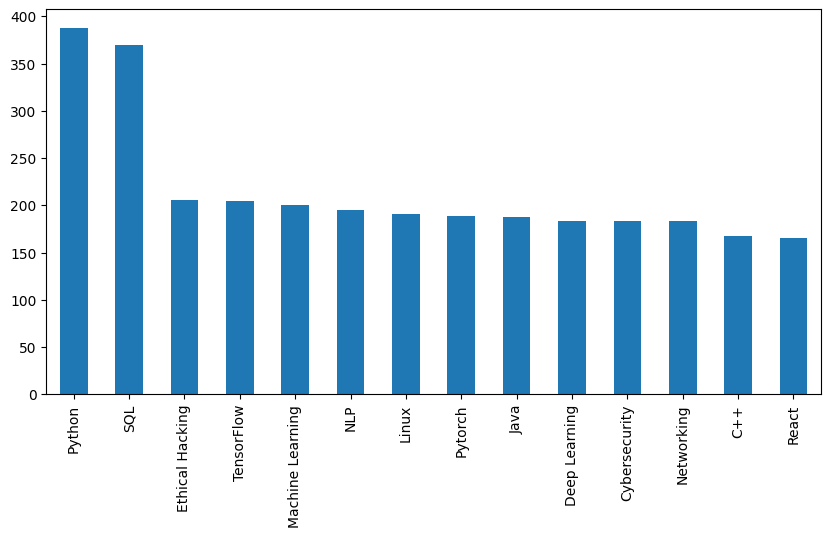

In [13]:
pd.Series(all_skills).value_counts().plot(kind='bar', figsize=(10,5))

In [14]:
df['Skill_Count'] = df['Skills'].apply(lambda x: len(x.split(',')))

In [15]:
df['Has_Certification'] = (df['Certifications'].notnull().astype(int))

In [16]:
def exp_level(x):
    if x <= 2:
        return 'Junior'
    elif x <= 5:
        return 'Mid'
    else:
        return 'Senior'

df['Experience_Level'] = (df['Experience (Years)'].apply(exp_level))

In [17]:
df['High_AI_Score'] = (df['AI Score (0-100)'] >= 80).astype(int)

In [18]:
df['High_Projects'] = (df['Projects Count'] >= 5).astype(int)

In [19]:
df.head()

,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100),Skill_Count,Has_Certification,Experience_Level,High_AI_Score,High_Projects
0,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100,3,0,Senior,1,1
1,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100,4,1,Senior,1,0
2,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70,3,1,Junior,0,1
3,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95,3,1,Senior,1,0
4,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100,3,0,Mid,1,1


In [20]:
df['Skills_Clean'] = df['Skills']

In [21]:
df['Skills_Clean'] = (df['Skills_Clean'].str.replace('Deep Learning', 'DeepLearning').str.replace('Machine Learning', 'MachineLearning').str.replace('Ethical Hacking', 'EthicalHacking'))

In [22]:
df['Recruiter Decision'] = df['Recruiter Decision'].map({
    'Hire':1,
    'Reject':0
})

##Text Feature Extraction using TF-IDF

The Skills_Clean column contains textual skill information.
TF-IDF vectorization is applied to convert skill keywords into numerical features suitable for machine learning algorithms.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_skills = tfidf.fit_transform(df['Skills_Clean'])

print(tfidf.get_feature_names_out())

['cybersecurity' 'deeplearning' 'ethicalhacking' 'java' 'linux'
 'machinelearning' 'networking' 'nlp' 'python' 'pytorch' 'react' 'sql'
 'tensorflow']


##ENCODING

In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Education'] = le.fit_transform(df['Education'])

In [25]:
le_exp = LabelEncoder()

df['Experience_Level'] = le_exp.fit_transform(
    df['Experience_Level']
)

In [26]:
extra_features = df[
    [
        'Experience (Years)',
        'Education',
        'Projects Count',
        'AI Score (0-100)',
        'Skill_Count',
        'Has_Certification',
        'High_AI_Score',
        'High_Projects',
        'Experience_Level'
    ]
]

In [27]:
extra_features.head()

,Experience (Years),Education,Projects Count,AI Score (0-100),Skill_Count,Has_Certification,High_AI_Score,High_Projects,Experience_Level
0,10,0,8,100,3,0,1,1,2
1,10,3,1,100,4,1,1,0,2
2,1,3,7,70,3,1,0,1,0
3,7,1,0,95,3,1,1,0,2
4,4,4,9,100,3,0,1,1,1


In [28]:
from scipy.sparse import hstack

X = hstack([X_skills, extra_features])

y = df['Recruiter Decision']

In [29]:
print(X.shape)

(1000, 22)


##Train-Test Split

In [ ]:
# Train - Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

## MODEL TRAINING

In [ ]:
#Logistic regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_lr)
)

In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",accuracy_score(y_test, y_pred_rf))

In [ ]:
#SVM
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print(
    "SVM Accuracy:",
    accuracy_score(y_test, y_pred_svm)
)

In [ ]:
# GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print(
    "Gradient Boosting Accuracy:",
    accuracy_score(y_test, y_pred_gb)
)

In [ ]:
#xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train_enc)

y_pred_xgb = xgb.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test_enc, y_pred_xgb)
)

##Evaluation

In [ ]:
print("Logistic Regression :", accuracy_score(y_test, y_pred_lr))
print("Random Forest       :", accuracy_score(y_test, y_pred_rf))
print("SVM                 :", accuracy_score(y_test, y_pred_svm))
print("Gradient Boosting   :", accuracy_score(y_test, y_pred_gb))
print("XGBoost             :", accuracy_score(y_test_enc, y_pred_xgb))

In [ ]:
print(classification_report(y_test, y_pred_rf))

##Save Model

In [ ]:
X_hire = df.drop(
    ['Name', 'Recruiter Decision', 'Salary Expectation ($)'],
    axis=1
)

X_hire = pd.get_dummies(X_hire)

joblib.dump(
    X_hire.columns.tolist(),
    "/content/drive/MyDrive/Workforce_Project/models/hire_reject_columns.pkl"
)

print("Hire/Reject columns saved:", len(X_hire.columns))

In [ ]:
joblib.dump(
    rf,
    "/content/drive/MyDrive/Workforce_Project/models/hire_reject_model.pkl"
)

print("Hire/Reject model saved")

In [30]:
## Final Deployment Pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

df_pipeline = df.copy()

X_pipeline = df_pipeline[
    [
        "Skills_Clean",
        "Experience (Years)",
        "Education",
        "Projects Count",
        "AI Score (0-100)",
        "Skill_Count",
        "Has_Certification",
        "High_AI_Score",
        "High_Projects",
        "Experience_Level"
    ]
]

y_pipeline = df_pipeline["Recruiter Decision"]

preprocessor = ColumnTransformer(
    transformers=[
        ("skills_tfidf", TfidfVectorizer(), "Skills_Clean"),
        (
            "num",
            StandardScaler(),
            [
                "Experience (Years)",
                "Projects Count",
                "AI Score (0-100)",
                "Skill_Count",
                "Has_Certification",
                "High_AI_Score",
                "High_Projects",
                "Experience_Level"
            ],
        ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Education"]),
    ]
)

hire_reject_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42))
    ]
)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pipeline,
    y_pipeline,
    test_size=0.2,
    random_state=42,
    stratify=y_pipeline
)

hire_reject_pipeline.fit(X_train_p, y_train_p)

y_pred_p = hire_reject_pipeline.predict(X_test_p)

print("Pipeline Accuracy:", accuracy_score(y_test_p, y_pred_p))
print(classification_report(y_test_p, y_pred_p))

joblib.dump(
    hire_reject_pipeline,
    "/content/drive/MyDrive/Workforce_Project/models/hire_reject_pipeline.pkl"
)

print("Final deployment pipeline saved")

Pipeline Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00       162

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Final deployment pipeline saved
